In [1]:
import torch
print("Torch Version:", torch.__version__)
import numpy as np
import pandas as pd
from sklearn.decomposition import non_negative_factorization
from collections import defaultdict
import numpy as np
import torch
import tqdm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch import Tensor
import torch.nn as nn

Torch Version: 2.6.0+cu124


In [2]:
import pandas as pd

# Load data
df = pd.read_json("/kaggle/input/amazon-music-2018/Digital_Music.json", lines=True)

# # Keep relevant columns and remove duplicates
# df = df[['user_id', 'parent_asin', 'text']].drop_duplicates()

# Compute word counts and filter reviews
df['word_count'] = df['reviewText'].str.split().str.len()
df = df[df['word_count'] >= 50]

# Filter products with >=5 interactions
# ---------------------------
min_interactions_product = 20

while True:
    product_counts = df.groupby('asin')['reviewerID'].nunique()
    valid_products = product_counts[product_counts >= min_interactions_product].index
    
    prev_len = len(df)
    df = df[df['asin'].isin(valid_products)]
    
    # stop when no more changes happen
    if len(df) == prev_len:
        break


min_interactions_user = 10

while True:
    user_counts = df.groupby('reviewerID')['asin'].nunique()
    valid_users = user_counts[user_counts >= min_interactions_user].index
    
    prev_len = len(df)
    df = df[df['reviewerID'].isin(valid_users)]
    
    # stop when no more changes happen
    if len(df) == prev_len:
        break

# # ---------------------------
# # Final stats
# ---------------------------
print(f"Filtered dataset size: {len(df)}")
print(f"Remaining unique users: {df['reviewerID'].nunique()}")
print(f"Remaining unique products: {df['asin'].nunique()}")

ratings_df = df[['reviewerID', 'asin']]


Filtered dataset size: 2027
Remaining unique users: 102
Remaining unique products: 663


In [3]:
import pandas as pd

# Load data
df = pd.read_json("/kaggle/input/amazon-music-2018/Digital_Music.json", lines=True)

# Keep relevant columns and remove duplicates
# df = df[['user_id', 'parent_asin', 'text']].drop_duplicates()
df = df[['reviewerID', 'asin', 'reviewText']].drop_duplicates()

# Compute word counts and filter reviews
df['word_count'] = df['reviewText'].str.split().str.len()
df = df[df['word_count'] >= 10]

# Filter for users who have reviewed at least 10 different products
df = df.groupby('reviewerID').filter(lambda x: x['asin'].nunique() >= 10)

filtered_df = df
print(f"Filtered dataset size: {len(df)}")
print(f"Remaining unique users: {df['reviewerID'].nunique()}")
print(f"Remaining unique products: {df['asin'].nunique()}")

Filtered dataset size: 146057
Remaining unique users: 6921
Remaining unique products: 93774


In [14]:
ratings_df = df[['reviewerID', 'asin']]

In [4]:
user2idx = {u: i for i, u in enumerate(ratings_df['reviewerID'].unique())}
item2idx = {m: i for i, m in enumerate(ratings_df['asin'].unique())}

ratings_df['reviewerID'] = ratings_df['reviewerID'].map(user2idx)
ratings_df['asin'] = ratings_df['asin'].map(item2idx)

num_users = len(user2idx)
num_items = len(item2idx)

# Create positive interactions
interactions = ratings_df[['reviewerID','asin']].values

# Train/test split
train_pos, test_pos = train_test_split(interactions, test_size=0.2, random_state=42)


ratings_df


/tmp/ipykernel_37/3256011153.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_df['reviewerID'] = ratings_df['reviewerID'].map(user2idx)
/tmp/ipykernel_37/3256011153.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_df['asin'] = ratings_df['asin'].map(item2idx)


,reviewerID,asin
4,0,0
66,1,1
85,2,2
138,3,3
144,4,3
...,...,...
1584001,3760,93769
1584010,4787,93770
1584019,3713,93771
1584028,330,93772


In [5]:
def negative_sampling(pos_interactions, num_users, num_items, num_neg=2):
    neg_samples = []
    pos_set = set((u, i) for u, i in pos_interactions)
    for (u, i) in pos_interactions:
        for _ in range(num_neg):
            j = np.random.randint(num_items)
            while (u, j) in pos_set:
                j = np.random.randint(num_items)
            neg_samples.append([u, j])
    return np.array(neg_samples)

train_neg = negative_sampling(train_pos, num_users, num_items)
test_neg = negative_sampling(test_pos, num_users, num_items, num_neg=98)

train_data = np.vstack([np.hstack([train_pos, np.ones((len(train_pos),1))]),
                        np.hstack([train_neg, np.zeros((len(train_neg),1))])])

test_data = np.vstack([np.hstack([test_pos, np.ones((len(test_pos),1))]),
                       np.hstack([test_neg, np.zeros((len(test_neg),1))])])

# Shuffle train data
np.random.shuffle(train_data)

# Shuffle test data
np.random.shuffle(test_data)

In [6]:
print("Train positives:", len(train_pos))
print("Test positives:", len(test_pos))
print("Train negatives:", train_neg.shape[0])
print("Test negatives:", test_neg.shape[0])


Train positives: 116845
Test positives: 29212
Train negatives: 233690
Test negatives: 2862776


In [7]:
class RecDataset(Dataset):
    def __init__(self, data):
        self.users = torch.LongTensor(data[:,0])
        self.items = torch.LongTensor(data[:,1])
        self.labels = torch.FloatTensor(data[:,2])
    def __len__(self): return len(self.users)
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

train_loader = DataLoader(RecDataset(train_data), batch_size=512, shuffle=True)
test_loader = DataLoader(RecDataset(test_data), batch_size=512, shuffle=False)


In [8]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=5, hidden_layers=[64,32,16,8]):
        super().__init__()
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.item_embed = nn.Embedding(num_items, embed_dim)

        layers = []
        input_size = embed_dim*2
        for h in hidden_layers:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.ReLU())
            input_size = h
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(input_size, 1)

    def forward(self, user, item):
        u = self.user_embed(user)
        i = self.item_embed(item)
        x = torch.cat([u, i], dim=-1)
        x = self.mlp(x)
        return torch.sigmoid(self.out(x)).squeeze()


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NCF(num_users, num_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCELoss()

for epoch in range(50):  # increase epochs
    model.train()
    total_loss = 0
    for users, items, labels in train_loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)
        preds = model(users, items)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss={total_loss/len(train_loader):.4f}")


Epoch 1, Loss=0.6383
Epoch 2, Loss=0.6364
Epoch 3, Loss=0.6340
Epoch 4, Loss=0.6177
Epoch 5, Loss=0.5771
Epoch 6, Loss=0.5044
Epoch 7, Loss=0.4101
Epoch 8, Loss=0.3270
Epoch 9, Loss=0.2693
Epoch 10, Loss=0.2328
Epoch 11, Loss=0.2102
Epoch 12, Loss=0.1955
Epoch 13, Loss=0.1873
Epoch 14, Loss=0.1831
Epoch 15, Loss=0.1844


KeyboardInterrupt: 

In [16]:
def evaluate_fast(model, test_pos, num_items, K=10, num_neg=99):
    model.eval()
    HR, NDCG = [], []
    with torch.no_grad():
        for (u, i) in test_pos:
            # Sample random negatives
            neg_items = np.random.choice(num_items, size=num_neg, replace=False)
            items = np.concatenate(([i], neg_items))
            
            u_tensor = torch.LongTensor([u] * len(items)).to(device)
            items_tensor = torch.LongTensor(items).to(device)
            
            scores = model(u_tensor, items_tensor).cpu().numpy()
            
            # rank
            rank = scores.argsort()[::-1]
            topK = items[rank[:K]]
            
            if i in topK:
                HR.append(1)
                idx = np.where(topK == i)[0][0]
                NDCG.append(1 / np.log2(idx+2))
            else:
                HR.append(0)
                NDCG.append(0)
    return np.mean(HR), np.mean(NDCG)
    
hr10, ndcg10 = evaluate_fast(model, test_pos, num_items, K=10)
print(f"[Personality NCF] HR@10={hr10:.4f}, NDCG@10={ndcg10:.4f}")
hr5, ndcg5 = evaluate_fast(model, test_pos, num_items, K=5)
print(f"[Personality NCF] HR@5={hr5:.4f}, NDCG@5={ndcg5:.4f}")

[Personality NCF] HR@10=0.1850, NDCG@10=0.1849
[Personality NCF] HR@5=0.1871, NDCG@5=0.1871


In [10]:
personality_tensor_rand = torch.rand((num_users, 5), dtype=torch.float32)

In [11]:
class NCF_Personality(nn.Module):
    def __init__(self, num_users, num_items, personality_tensor, 
                 embed_dim=16, hidden_layers=[64,32,16,8]):
        super().__init__()
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.item_embed = nn.Embedding(num_items, embed_dim)

        # store personality features for all users
        self.register_buffer("personality", personality_tensor)

        layers = []
        input_size = embed_dim*2 + personality_tensor.shape[1]  # concat with 5 OCEAN traits
        for h in hidden_layers:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.ReLU())
            input_size = h
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(input_size, 1)

    def forward(self, user, item):
        u = self.user_embed(user)
        i = self.item_embed(item)
        p = self.personality[user]   # get personality row for that user
        x = torch.cat([u, i, p], dim=-1)
        x = self.mlp(x)
        return torch.sigmoid(self.out(x)).squeeze()


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_p = NCF_Personality(num_users, num_items, personality_tensor_rand).to(device)
optimizer = torch.optim.Adam(model_p.parameters(), lr=0.1)
criterion = nn.BCELoss()

for epoch in range(100):
    model_p.train()
    total_loss = 0
    for users, items, labels in train_loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)
        preds = model_p(users, items)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[Personality NCF] Epoch {epoch+1}, Loss={total_loss/len(train_loader):.4f}")


[Personality NCF] Epoch 1, Loss=0.6378
[Personality NCF] Epoch 2, Loss=0.6369
[Personality NCF] Epoch 3, Loss=0.6369


KeyboardInterrupt: 

In [48]:
hr5, ndcg5 = evaluate_fast(model_p, test_pos, num_items, K=10)
print(f"[Personality NCF] HR@5={hr5:.4f}, NDCG@5={ndcg5:.4f}")

[Personality NCF] HR@5=0.2635, NDCG@5=0.2557


Epoch 1/150 | Train Loss=0.7184 | HR@5=0.0296 | NDCG@5=0.0133
Epoch 2/150 | Train Loss=0.7091 | HR@5=0.0493 | NDCG@5=0.0314
Epoch 3/150 | Train Loss=0.6907 | HR@5=0.0443 | NDCG@5=0.0232
Epoch 4/150 | Train Loss=0.6584 | HR@5=0.0567 | NDCG@5=0.0311
Epoch 5/150 | Train Loss=0.6424 | HR@5=0.0493 | NDCG@5=0.0270
Epoch 6/150 | Train Loss=0.6397 | HR@5=0.0443 | NDCG@5=0.0261
Epoch 7/150 | Train Loss=0.6378 | HR@5=0.0345 | NDCG@5=0.0192
Epoch 8/150 | Train Loss=0.6352 | HR@5=0.0394 | NDCG@5=0.0229
Epoch 9/150 | Train Loss=0.6347 | HR@5=0.0493 | NDCG@5=0.0269
Epoch 10/150 | Train Loss=0.6345 | HR@5=0.0517 | NDCG@5=0.0294
Epoch 11/150 | Train Loss=0.6344 | HR@5=0.0542 | NDCG@5=0.0314
Epoch 12/150 | Train Loss=0.6335 | HR@5=0.0640 | NDCG@5=0.0343
Epoch 13/150 | Train Loss=0.6307 | HR@5=0.0591 | NDCG@5=0.0350
Epoch 14/150 | Train Loss=0.6298 | HR@5=0.0616 | NDCG@5=0.0346
Epoch 15/150 | Train Loss=0.6309 | HR@5=0.0665 | NDCG@5=0.0346
Epoch 16/150 | Train Loss=0.6289 | HR@5=0.0591 | NDCG@5=0.0372
E

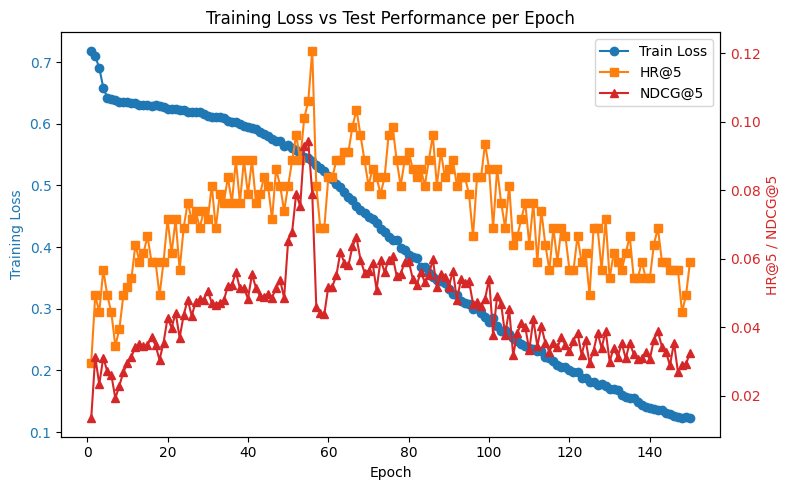

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NCF(num_users, num_items).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Store metrics for plotting
train_losses = []
test_hr = []
test_ndcg = []

num_epochs = 150

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for users, items, labels in train_loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)
        preds = model(users, items)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Evaluate on test set after each epoch
    hr5, ndcg5 = evaluate_fast(model, test_pos, num_items, K=5)
    test_hr.append(hr5)
    test_ndcg.append(ndcg5)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss={avg_loss:.4f} | HR@5={hr5:.4f} | NDCG@5={ndcg5:.4f}")

# ---- Plotting ----
epochs = np.arange(1, num_epochs + 1)

fig, ax1 = plt.subplots(figsize=(8,5))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(epochs, train_losses, color=color, marker='o', label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # second y-axis
color = 'tab:red'
ax2.set_ylabel('HR@5 / NDCG@5', color=color)
ax2.plot(epochs, test_hr, color='tab:orange', marker='s', label='HR@5')
ax2.plot(epochs, test_ndcg, color='tab:red', marker='^', label='NDCG@5')
ax2.tick_params(axis='y', labelcolor=color)

# Add combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='best')

plt.title('Training Loss vs Test Performance per Epoch')
plt.tight_layout()
plt.show()


Epoch 1/150 | Train Loss=0.7271 | HR@5=0.0443 | NDCG@5=0.0271
Epoch 2/150 | Train Loss=0.7179 | HR@5=0.0517 | NDCG@5=0.0314
Epoch 3/150 | Train Loss=0.7057 | HR@5=0.0517 | NDCG@5=0.0290
Epoch 4/150 | Train Loss=0.6853 | HR@5=0.0468 | NDCG@5=0.0303
Epoch 5/150 | Train Loss=0.6529 | HR@5=0.0443 | NDCG@5=0.0276
Epoch 6/150 | Train Loss=0.6378 | HR@5=0.0468 | NDCG@5=0.0306
Epoch 7/150 | Train Loss=0.6348 | HR@5=0.0616 | NDCG@5=0.0396
Epoch 8/150 | Train Loss=0.6316 | HR@5=0.0640 | NDCG@5=0.0413
Epoch 9/150 | Train Loss=0.6307 | HR@5=0.0616 | NDCG@5=0.0378
Epoch 10/150 | Train Loss=0.6277 | HR@5=0.0665 | NDCG@5=0.0386
Epoch 11/150 | Train Loss=0.6276 | HR@5=0.0813 | NDCG@5=0.0472
Epoch 12/150 | Train Loss=0.6251 | HR@5=0.0665 | NDCG@5=0.0408
Epoch 13/150 | Train Loss=0.6252 | HR@5=0.0714 | NDCG@5=0.0456
Epoch 14/150 | Train Loss=0.6241 | HR@5=0.0813 | NDCG@5=0.0521
Epoch 15/150 | Train Loss=0.6202 | HR@5=0.0837 | NDCG@5=0.0482
Epoch 16/150 | Train Loss=0.6206 | HR@5=0.0813 | NDCG@5=0.0529
E

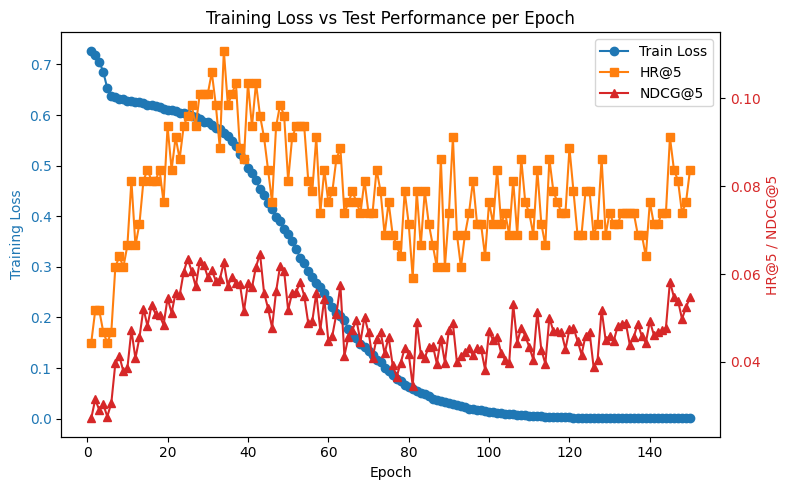

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_p = NCF_Personality(num_users, num_items, personality_tensor_rand).to(device)
optimizer = torch.optim.Adam(model_p.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Store metrics for plotting
train_losses = []
test_hr = []
test_ndcg = []

num_epochs = 150

for epoch in range(num_epochs):
    model_p.train()
    total_loss = 0
    for users, items, labels in train_loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)
        preds = model_p(users, items)
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Evaluate on test set after each epoch
    hr5, ndcg5 = evaluate_fast(model_p, test_pos, num_items, K=5)
    test_hr.append(hr5)
    test_ndcg.append(ndcg5)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss={avg_loss:.4f} | HR@5={hr5:.4f} | NDCG@5={ndcg5:.4f}")

# ---- Plotting ----
epochs = np.arange(1, num_epochs + 1)

fig, ax1 = plt.subplots(figsize=(8,5))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(epochs, train_losses, color=color, marker='o', label='Train Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # second y-axis
color = 'tab:red'
ax2.set_ylabel('HR@5 / NDCG@5', color=color)
ax2.plot(epochs, test_hr, color='tab:orange', marker='s', label='HR@5')
ax2.plot(epochs, test_ndcg, color='tab:red', marker='^', label='NDCG@5')
ax2.tick_params(axis='y', labelcolor=color)

# Add combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='best')

plt.title('Training Loss vs Test Performance per Epoch')
plt.tight_layout()
plt.show()
